<a href="https://colab.research.google.com/github/Namamigit/JustRentIt-Backend/blob/main/genailab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Input words
words = ["The", "cat", "drank", "milk"]

# Word embeddings (4-dimensional for simplicity)
embeddings = np.array([
    [1, 0, 1, 0],   # The
    [0, 2, 1, 1],   # cat
    [1, 1, 2, 0],   # drank
    [2, 1, 0, 2]    # milk
], dtype=float)

# Weight matrices
np.random.seed(42)
Wq = np.random.rand(4,4)
Wk = np.random.rand(4,4)
Wv = np.random.rand(4,4)

# Compute Q, K, V
Q = embeddings @ Wq
K = embeddings @ Wk
V = embeddings @ Wv

# Attention scores
scores = Q @ K.T

# Scale scores
dk = K.shape[1]
scores = scores / np.sqrt(dk)

# Softmax
def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / exp.sum(axis=1, keepdims=True)

attention = softmax(scores)

# Output vectors
output = attention @ V

print("Attention Matrix:")
print(np.round(attention,3))

Attention Matrix:
[[0.051 0.194 0.443 0.312]
 [0.026 0.236 0.452 0.286]
 [0.013 0.148 0.589 0.25 ]
 [0.006 0.15  0.368 0.475]]


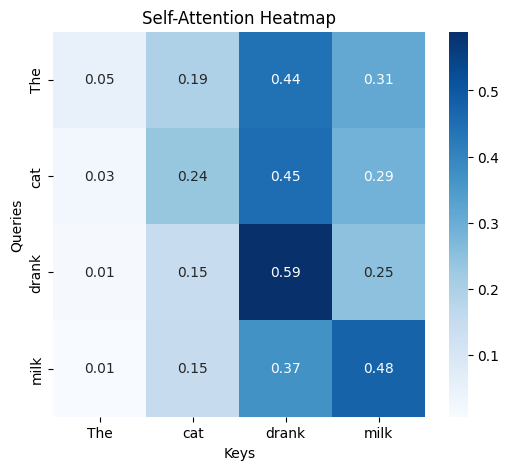

In [3]:
plt.figure(figsize=(6,5))
sns.heatmap(
    attention,
    annot=True,
    cmap="Blues",
    xticklabels=words,
    yticklabels=words,
    fmt=".2f"
)

plt.title("Self-Attention Heatmap")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.show()

In [4]:
encoder_words = ["I", "love", "AI"]
decoder_words = ["J'aime", "IA"]

# Encoder embeddings
encoder = np.array([
    [1,0,1,1],
    [2,1,0,1],
    [1,2,1,0]
],dtype=float)

# Decoder embeddings
decoder = np.array([
    [2,1,1,0],
    [1,2,2,1]
],dtype=float)

# Random weights
np.random.seed(1)

Wq = np.random.rand(4,4)
Wk = np.random.rand(4,4)
Wv = np.random.rand(4,4)

Q = decoder @ Wq
K = encoder @ Wk
V = encoder @ Wv

scores = Q @ K.T
scores = scores / np.sqrt(K.shape[1])

attention = softmax(scores)

output = attention @ V

print(attention)

[[0.03680438 0.20111085 0.76208477]
 [0.00921539 0.13938731 0.8513973 ]]


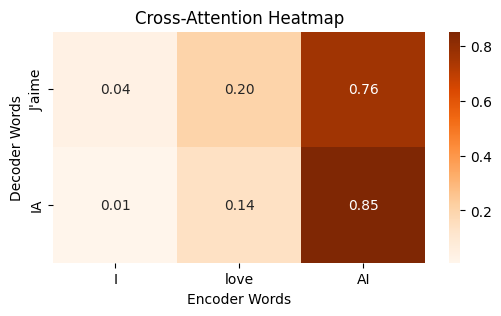

In [5]:
plt.figure(figsize=(6,3))

sns.heatmap(
    attention,
    annot=True,
    cmap="Oranges",
    xticklabels=encoder_words,
    yticklabels=decoder_words,
    fmt=".2f"
)

plt.title("Cross-Attention Heatmap")
plt.xlabel("Encoder Words")
plt.ylabel("Decoder Words")
plt.show()

In [8]:
import numpy as np

# Re-calculating self-attention matrix to resolve the IndexError.
# This is necessary because the global 'attention' variable was overwritten by cross-attention.

# Input words (already defined globally)
# words = ["The", "cat", "drank", "milk"]

# Word embeddings (4-dimensional for simplicity, already defined globally)
# embeddings = np.array([
#     [1, 0, 1, 0],   # The
#     [0, 2, 1, 1],   # cat
#     [1, 1, 2, 0],   # drank
#     [2, 1, 0, 2]    # milk
# ], dtype=float)

# Weight matrices - re-initialize with the original seed for self-attention
np.random.seed(42) # Original seed from self-attention calculation
Wq_self = np.random.rand(4,4)
Wk_self = np.random.rand(4,4)
Wv_self = np.random.rand(4,4)

# Compute Q, K, V for self-attention
Q_self = embeddings @ Wq_self
K_self = embeddings @ Wk_self
V_self = embeddings @ Wv_self

# Attention scores for self-attention
scores_self = Q_self @ K_self.T

# Scale scores
dk_self = K_self.shape[1]
scores_self = scores_self / np.sqrt(dk_self)

# Softmax (function 'softmax' is already defined globally)
self_attention_matrix = softmax(scores_self)

print("Self Attention Scores")
for i, word in enumerate(words):
    print(f"\nQuery Word: {word}")
    for j, key in enumerate(words):
        print(f"  {key:6s} -> {self_attention_matrix[i][j]:.3f}")

Self Attention Scores

Query Word: The
  The    -> 0.051
  cat    -> 0.194
  drank  -> 0.443
  milk   -> 0.312

Query Word: cat
  The    -> 0.026
  cat    -> 0.236
  drank  -> 0.452
  milk   -> 0.286

Query Word: drank
  The    -> 0.013
  cat    -> 0.148
  drank  -> 0.589
  milk   -> 0.250

Query Word: milk
  The    -> 0.006
  cat    -> 0.150
  drank  -> 0.368
  milk   -> 0.475


In [7]:
print("\nCross Attention Scores")

for i, word in enumerate(decoder_words):
    print(f"\nDecoder Query: {word}")
    for j, key in enumerate(encoder_words):
        print(f"  {key:5s} -> {attention[i][j]:.3f}")


Cross Attention Scores

Decoder Query: J'aime
  I     -> 0.037
  love  -> 0.201
  AI    -> 0.762

Decoder Query: IA
  I     -> 0.009
  love  -> 0.139
  AI    -> 0.851
